In [1]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



  Intermissa  —  183 rows × 18 columns
                   dtype  count  missing  missing_%  n_unique        min  \
id                   str    183        0        0.0       183       <NA>   
junctions_count    Int64    183        0        0.0        13       11.0   
junctions_cx     float32    183        0        0.0       182   358.6875   
junctions_cy     float32    183        0        0.0       176    84.6875   
junctions_x_max  float32    183        0        0.0        78      569.0   
junctions_x_min  float32    183        0        0.0        78       32.0   
junctions_x_std  float32    183        0        0.0       183  95.096001   
junctions_y_max  float32    183        0        0.0        64      148.0   
junctions_y_min  float32    183        0        0.0        25       21.0   
junctions_y_std  float32    183        0        0.0       183  32.806217   
label                str    183        0        0.0         1       <NA>   
skeleton_count     Int64    183        0        

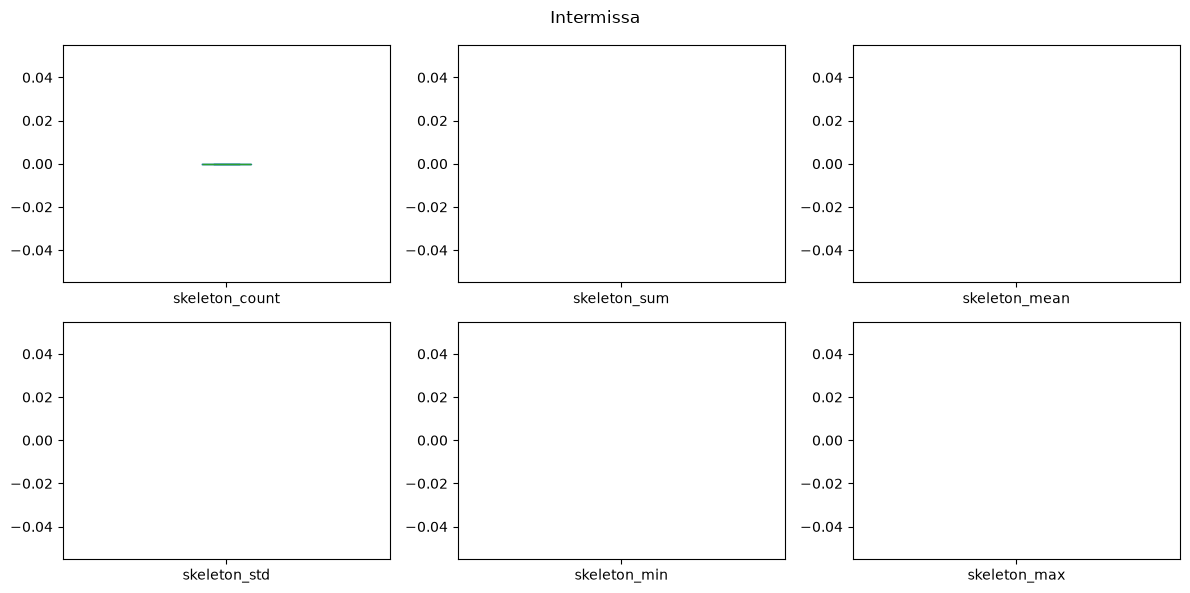

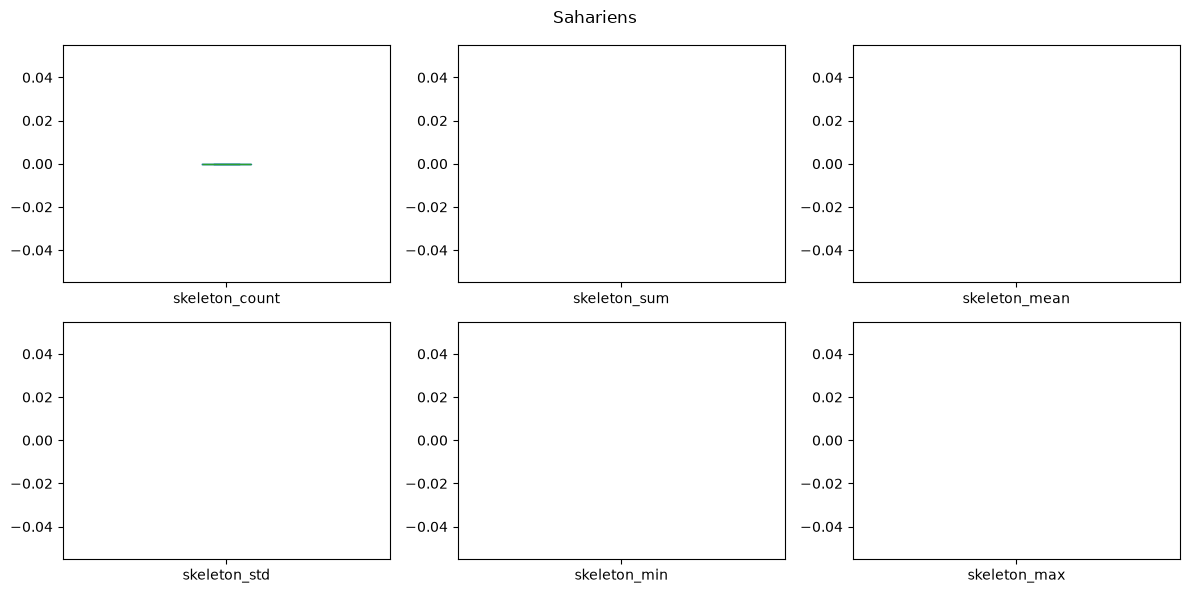

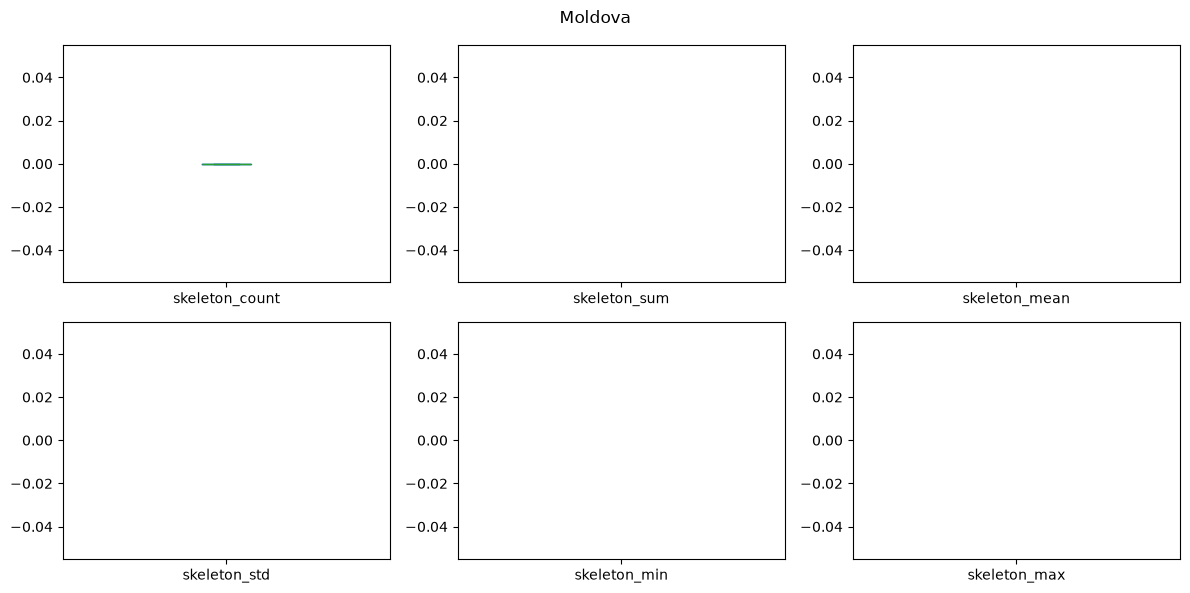

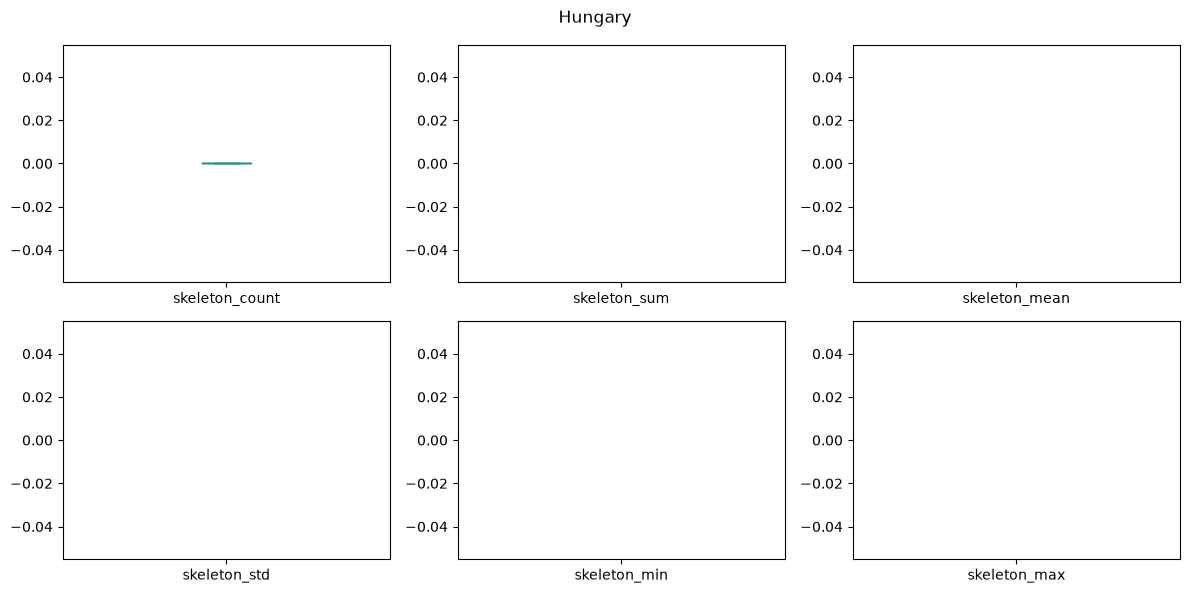

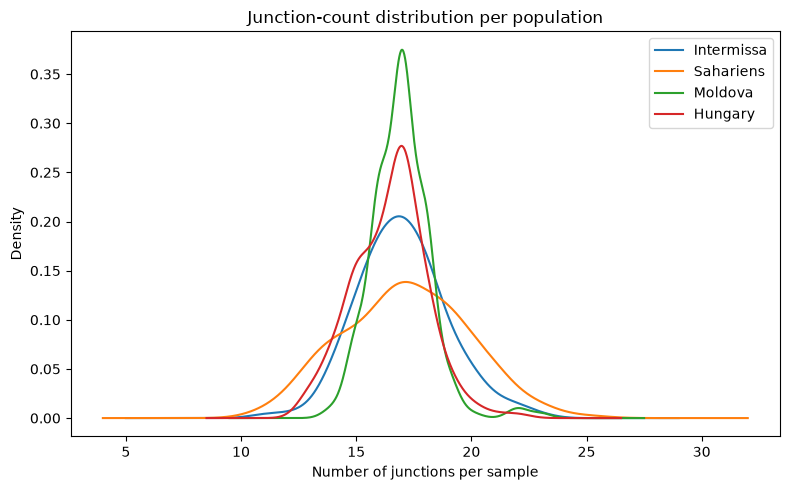


===== CONVERSION CHECK =====
  ⚠ Intermissa: all-NaN columns -> ['skeleton_sum', 'skeleton_mean', 'skeleton_std', 'skeleton_min', 'skeleton_max', 'skeleton_median']
  ⚠ Sahariens: all-NaN columns -> ['skeleton_sum', 'skeleton_mean', 'skeleton_std', 'skeleton_min', 'skeleton_max', 'skeleton_median']
  ⚠ Moldova: all-NaN columns -> ['skeleton_sum', 'skeleton_mean', 'skeleton_std', 'skeleton_min', 'skeleton_max', 'skeleton_median']
  ⚠ Hungary: all-NaN columns -> ['skeleton_sum', 'skeleton_mean', 'skeleton_std', 'skeleton_min', 'skeleton_max', 'skeleton_median']


In [12]:
"""
AF variant-size analysis pipeline
---------------------------------
Loads the four population CSVs, parses `skeleton` (comma-separated values)
and `junctions` (semicolon-separated x,y pairs) into numeric feature columns,
then describes the variant sizes per column and compares across populations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. CONFIG
# ============================================================
FILES = {
    "Intermissa": "AF_Intermissa.csv",
    "Sahariens" : "AF_sahariens.csv",
    "Moldova"   : "AF_Moldova.csv",
    "Hungary"   : "AF_Hungary.csv",
}

SKELETON_COL  = "skeleton"
JUNCTIONS_COL = "junctions"

# ============================================================
# 1. PARSERS
# ============================================================
def parse_skeleton(val):
    """'0,0,0,0,0,0,0' -> np.array([0., 0., ...])"""
    if pd.isna(val):
        return np.array([], dtype='float32')
    parts = [p for p in str(val).split(',') if p.strip() != '']
    try:
        return np.array([float(p) for p in parts], dtype='float32')
    except ValueError:
        return np.array([], dtype='float32')

def parse_junctions(val):
    """'451,29;454,36;373,43' -> np.array([[451,29],[454,36],[373,43]])"""
    if pd.isna(val):
        return np.empty((0, 2), dtype='float32')
    pairs = []
    for chunk in str(val).split(';'):
        chunk = chunk.strip()
        if not chunk:
            continue
        parts = chunk.split(',')
        if len(parts) == 2:
            try:
                pairs.append((float(parts[0]), float(parts[1])))
            except ValueError:
                continue
    return (np.array(pairs, dtype='float32') if pairs
            else np.empty((0, 2), dtype='float32'))

# ============================================================
# 2. FEATURE EXTRACTION
# ============================================================
def skeleton_features(df, col=SKELETON_COL):
    """Expand `skeleton` into per-row aggregated numeric features."""
    arrs = df[col].apply(parse_skeleton)

    df[f'{col}_count']  = arrs.apply(len).astype('Int64')
    df[f'{col}_sum']    = arrs.apply(lambda a: a.sum()       if len(a) else np.nan)
    df[f'{col}_mean']   = arrs.apply(lambda a: a.mean()      if len(a) else np.nan)
    df[f'{col}_std']    = arrs.apply(lambda a: a.std()       if len(a) else np.nan)
    df[f'{col}_min']    = arrs.apply(lambda a: a.min()       if len(a) else np.nan)
    df[f'{col}_max']    = arrs.apply(lambda a: a.max()       if len(a) else np.nan)
    df[f'{col}_median'] = arrs.apply(lambda a: np.median(a)  if len(a) else np.nan)
    return df.drop(columns=[col])

def junction_features(df, col=JUNCTIONS_COL):
    """Expand `junctions` into count + spatial summary features."""
    arrs = df[col].apply(parse_junctions)

    df[f'{col}_count'] = arrs.apply(len).astype('Int64')

    df[f'{col}_cx']    = arrs.apply(lambda a: a[:,0].mean() if len(a) else np.nan)
    df[f'{col}_cy']    = arrs.apply(lambda a: a[:,1].mean() if len(a) else np.nan)
    df[f'{col}_x_std'] = arrs.apply(lambda a: a[:,0].std()  if len(a) else np.nan)
    df[f'{col}_y_std'] = arrs.apply(lambda a: a[:,1].std()  if len(a) else np.nan)
    df[f'{col}_x_min'] = arrs.apply(lambda a: a[:,0].min()  if len(a) else np.nan)
    df[f'{col}_x_max'] = arrs.apply(lambda a: a[:,0].max()  if len(a) else np.nan)
    df[f'{col}_y_min'] = arrs.apply(lambda a: a[:,1].min()  if len(a) else np.nan)
    df[f'{col}_y_max'] = arrs.apply(lambda a: a[:,1].max()  if len(a) else np.nan)
    return df.drop(columns=[col])

# ============================================================
# 3. LOAD + CONVERT
# ============================================================
dfs = {name: pd.read_csv(path) for name, path in FILES.items()}

for name in dfs:
    if SKELETON_COL in dfs[name].columns:
        dfs[name] = skeleton_features(dfs[name], SKELETON_COL)
    if JUNCTIONS_COL in dfs[name].columns:
        dfs[name] = junction_features(dfs[name], JUNCTIONS_COL)

# ============================================================
# 4. PER-DATAFRAME STATS
# ============================================================
def describe_columns(df, name):
    num = df.select_dtypes(include='number')

    summary = pd.DataFrame({
        'dtype'     : df.dtypes,
        'count'     : df.count(),
        'missing'   : df.isna().sum(),
        'missing_%' : (df.isna().sum() / len(df) * 100).round(2),
        'n_unique'  : df.nunique(),
        'min'       : num.min(),
        'max'       : num.max(),
        'range'     : num.max() - num.min(),
        'mean'      : num.mean(),
        'std'       : num.std(),
        'cv_%'      : (num.std() / num.mean() * 100).round(2),
    })

    print(f"\n{'='*80}")
    print(f"  {name}  —  {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"{'='*80}")
    print(summary)
    return summary

stats = {name: describe_columns(df, name) for name, df in dfs.items()}

# ============================================================
# 5. COMPACT PER-COLUMN SNAPSHOT
# ============================================================
def column_snapshot(df, name):
    print(f"\n### {name} ###")
    for col in df.columns:
        s = df[col].dropna()
        if pd.api.types.is_numeric_dtype(s):
            print(f"  {col:25s} | n={len(s):5d} | "
                  f"min={s.min():>12.3g} | max={s.max():>12.3g} | "
                  f"range={s.max()-s.min():>12.3g} | std={s.std():>12.3g}")
        else:
            mode = s.mode().iloc[0] if not s.mode().empty else 'N/A'
            print(f"  {col:25s} | n={len(s):5d} | "
                  f"{s.nunique()} unique | most common: {mode}")

for name, df in dfs.items():
    column_snapshot(df, name)

# ============================================================
# 6. CROSS-POPULATION COMPARISON
# ============================================================
def compare_ranges(dfs_dict):
    comparison = {}
    for name, df in dfs_dict.items():
        num = df.select_dtypes(include='number')
        comparison[name] = pd.Series({
            col: f"{num[col].min():.2f} → {num[col].max():.2f} "
                 f"(range={num[col].max()-num[col].min():.2f}, "
                 f"std={num[col].std():.2f})"
            for col in num.columns
        })
    return pd.DataFrame(comparison)

print("\n\n===== CROSS-POPULATION COMPARISON =====")
print(compare_ranges(dfs))

# ============================================================
# 7. JUNCTION-COUNT SPECIFIC SUMMARY (the "variant size" metric)
# ============================================================
def junction_stats(df, name):
    col = f'{JUNCTIONS_COL}_count'
    if col not in df.columns:
        return
    s = df[col].dropna()
    print(f"\n{name} — junction counts per sample:")
    print(f"  n       = {len(s)}")
    print(f"  min     = {s.min()}")
    print(f"  max     = {s.max()}")
    print(f"  mean    = {s.mean():.2f}")
    print(f"  median  = {s.median()}")
    print(f"  std     = {s.std():.2f}")
    print(f"  range   = {s.max() - s.min()}")
    print(f"  unique  = {sorted(s.unique())[:20]}"
          f"{' ...' if s.nunique() > 20 else ''}")

print("\n\n===== JUNCTION-COUNT SUMMARY =====")
for name, df in dfs.items():
    junction_stats(df, name)

def skeleton_stats(df, name):
    col = f'{SKELETON_COL}_count'
    if col not in df.columns:
        return
    s = df[col].dropna()
    print(f"\n{name} — skeleton value counts per sample:")
    print(f"  n       = {len(s)}")
    print(f"  min     = {s.min()}")
    print(f"  max     = {s.max()}")
    print(f"  mean    = {s.mean():.2f}")
    print(f"  median  = {s.median()}")
    print(f"  std     = {s.std():.2f}")
    print(f"  unique  = {sorted(s.unique())[:20]}"
          f"{' ...' if s.nunique() > 20 else ''}")

print("\n\n===== SKELETON-COUNT SUMMARY =====")
for name, df in dfs.items():
    skeleton_stats(df, name)

# ============================================================
# 8. VISUALIZATION
# ============================================================
def plot_variants(dfs_dict, max_cols=6):
    for name, df in dfs_dict.items():
        num = df.select_dtypes(include='number')
        cols = num.columns[:max_cols]
        if len(cols) == 0:
            continue
        num[cols].plot(kind='box', subplots=True, layout=(-1, 3),
                       figsize=(12, 3 * ((len(cols) + 2) // 3)),
                       sharex=False, sharey=False, title=f"{name}")
        plt.tight_layout()
        plt.show()

plot_variants(dfs)

# Junction-count distribution per population (nice overview)
fig, ax = plt.subplots(figsize=(8, 5))
for name, df in dfs.items():
    col = f'{JUNCTIONS_COL}_count'
    if col in df.columns:
        df[col].dropna().plot(kind='kde', ax=ax, label=name)
ax.set_xlabel('Number of junctions per sample')
ax.set_title('Junction-count distribution per population')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 9. SANITY CHECK — leftovers / failures
# ============================================================
print("\n===== CONVERSION CHECK =====")
for name, df in dfs.items():
    num = df.select_dtypes(include='number')
    all_nan = [c for c in num.columns if num[c].isna().all()]
    if all_nan:
        print(f"  ⚠ {name}: all-NaN columns -> {all_nan}")
    else:
        print(f"  ✓ {name}: no all-NaN numeric columns")


Dropped all-NaN skeleton columns: ['skeleton_sum', 'skeleton_mean', 'skeleton_std', 'skeleton_min', 'skeleton_max', 'skeleton_median']
No missing values remain.

Final dataset shape: (732, 11)
label
Intermissa    183
Sahariens     183
Moldova       183
Hungary       183
Name: count, dtype: int64

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV accuracy: 0.662

Test accuracy: 0.728

Classification report:
              precision    recall  f1-score   support

     Hungary       0.69      0.73      0.71        37
  Intermissa       0.69      0.50      0.58        36
     Moldova       0.71      0.81      0.76        37
   Sahariens       0.80      0.86      0.83        37

    accuracy                           0.73       147
   macro avg       0.72      0.73      0.72       147
weighted avg       0.72      0.73      0.72       147



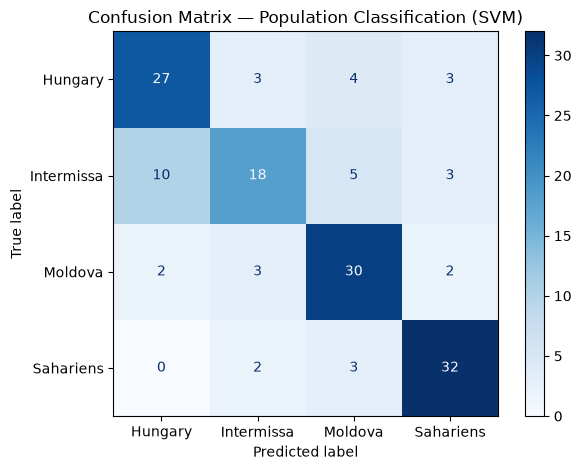

In [13]:
"""
SVM classifier for population classification (Intermissa / Sahariens / Moldova / Hungary)
--------------------------------------------------------------------------------------
Builds on the existing skeleton/junctions parsing pipeline, then:
  1. cleans the data (drops id + all-NaN skeleton columns)
  2. combines all 4 populations into one dataset
  3. scales features
  4. tunes and trains an SVM
  5. evaluates on a held-out test set
"""

import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# 0. CONFIG
# ============================================================
FILES = {
    "Intermissa": "AF_Intermissa.csv",
    "Sahariens" : "AF_sahariens.csv",
    "Moldova"   : "AF_Moldova.csv",
    "Hungary"   : "AF_Hungary.csv",
}

SKELETON_COL  = "skeleton"
JUNCTIONS_COL = "junctions"

# ============================================================
# 1. PARSERS (same as before)
# ============================================================
def parse_skeleton(val):
    if pd.isna(val):
        return np.array([], dtype='float32')
    parts = [p for p in str(val).split(',') if p.strip() != '']
    try:
        return np.array([float(p) for p in parts], dtype='float32')
    except ValueError:
        return np.array([], dtype='float32')

def parse_junctions(val):
    if pd.isna(val):
        return np.empty((0, 2), dtype='float32')
    pairs = []
    for chunk in str(val).split(';'):
        chunk = chunk.strip()
        if not chunk:
            continue
        parts = chunk.split(',')
        if len(parts) == 2:
            try:
                pairs.append((float(parts[0]), float(parts[1])))
            except ValueError:
                continue
    return (np.array(pairs, dtype='float32') if pairs
            else np.empty((0, 2), dtype='float32'))

def skeleton_features(df, col=SKELETON_COL):
    arrs = df[col].apply(parse_skeleton)
    df[f'{col}_count']  = arrs.apply(len).astype('Int64')
    df[f'{col}_sum']    = arrs.apply(lambda a: a.sum()      if len(a) else np.nan)
    df[f'{col}_mean']   = arrs.apply(lambda a: a.mean()     if len(a) else np.nan)
    df[f'{col}_std']    = arrs.apply(lambda a: a.std()      if len(a) else np.nan)
    df[f'{col}_min']    = arrs.apply(lambda a: a.min()      if len(a) else np.nan)
    df[f'{col}_max']    = arrs.apply(lambda a: a.max()      if len(a) else np.nan)
    df[f'{col}_median'] = arrs.apply(lambda a: np.median(a) if len(a) else np.nan)
    return df.drop(columns=[col])

def junction_features(df, col=JUNCTIONS_COL):
    arrs = df[col].apply(parse_junctions)
    df[f'{col}_count'] = arrs.apply(len).astype('Int64')
    df[f'{col}_cx']    = arrs.apply(lambda a: a[:, 0].mean() if len(a) else np.nan)
    df[f'{col}_cy']    = arrs.apply(lambda a: a[:, 1].mean() if len(a) else np.nan)
    df[f'{col}_x_std'] = arrs.apply(lambda a: a[:, 0].std()  if len(a) else np.nan)
    df[f'{col}_y_std'] = arrs.apply(lambda a: a[:, 1].std()  if len(a) else np.nan)
    df[f'{col}_x_min'] = arrs.apply(lambda a: a[:, 0].min()  if len(a) else np.nan)
    df[f'{col}_x_max'] = arrs.apply(lambda a: a[:, 0].max()  if len(a) else np.nan)
    df[f'{col}_y_min'] = arrs.apply(lambda a: a[:, 1].min()  if len(a) else np.nan)
    df[f'{col}_y_max'] = arrs.apply(lambda a: a[:, 1].max()  if len(a) else np.nan)
    return df.drop(columns=[col])

# ============================================================
# 2. LOAD, PARSE, LABEL
# ============================================================
dfs = {}
for name, path in FILES.items():
    df = pd.read_csv(path)
    if SKELETON_COL in df.columns:
        df = skeleton_features(df, SKELETON_COL)
    if JUNCTIONS_COL in df.columns:
        df = junction_features(df, JUNCTIONS_COL)
    df['label'] = name
    dfs[name] = df

full_df = pd.concat(dfs.values(), ignore_index=True)

# ============================================================
# 3. CLEANING
# ============================================================
# Drop identifier column
full_df = full_df.drop(columns=['id'], errors='ignore')

# Drop the all-NaN skeleton_* derived columns (no signal — skeleton data was empty)
skeleton_derived = [c for c in full_df.columns if c.startswith('skeleton_')]
all_nan_cols = [c for c in skeleton_derived if full_df[c].isna().all()]
full_df = full_df.drop(columns=all_nan_cols)
print(f"Dropped all-NaN skeleton columns: {all_nan_cols}")

# Sanity check: any remaining missing values?
missing = full_df.isna().sum()
missing = missing[missing > 0]
if len(missing):
    print("Remaining missing values:\n", missing)
    full_df = full_df.dropna()
else:
    print("No missing values remain.")

print(f"\nFinal dataset shape: {full_df.shape}")
print(full_df['label'].value_counts())

# ============================================================
# 4. FEATURES / TARGET
# ============================================================
X = full_df.drop(columns=['label'])
y = full_df['label']

le = LabelEncoder()
y_enc = le.fit_transform(y)

# ============================================================
# 5. TRAIN/TEST SPLIT (stratified to preserve class balance)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# ============================================================
# 6. SCALING (fit on train only, to avoid leakage)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ============================================================
# 7. HYPERPARAMETER TUNING
# ============================================================
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV a`ccuracy: {grid.best_score_:.3f}")

best_model = grid.best_estimator_

# ============================================================
# 8. EVALUATION
# ============================================================
y_pred = best_model.predict(X_test_scaled)

print(f"\nTest accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Population Classification (SVM)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# ============================================================
# 9. FEATURE IMPORTANCE (only meaningful for linear kernel)
# ============================================================
if best_model.kernel == 'linear':
    importance = np.abs(best_model.coef_).mean(axis=0)
    feat_importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)
    print("\nTop features by mean |coefficient| (one-vs-rest):")
    print(feat_importance.head(10))